In [ ]:
!pip install -q scikit-learn matplotlib


In [ ]:
import os, random, cv2, numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from glob import glob
from sklearn.metrics import accuracy_score
import torchvision.models as models


In [ ]:
BASE_PATH = "/content/drive/MyDrive/LungNodule_Dataset/lungnodulenewimagedataset"

TRAIN_DIR = os.path.join(BASE_PATH, "train_set")
TEST_DIR  = os.path.join(BASE_PATH, "test_set")

IMG_SIZE = (224, 224)
CLASSES = ["nodule", "non nodule"]   # exact folder names

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

print(f"Base Path: {BASE_PATH}")
if os.path.exists(BASE_PATH):
    print(f"Base Path exists. Listing contents:")
    for root, dirs, files in os.walk(BASE_PATH):
        level = root.replace(BASE_PATH, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files[:5]: # Print only first 5 files to avoid large output
            print(f'{subindent}{f}')
        if len(files) > 5:
            print(f'{subindent}... ({len(files) - 5} more files)')
else:
    print(f"Error: BASE_PATH '{BASE_PATH}' does not exist. Please check your Google Drive mount and path.")

Using device: cuda
Base Path: /content/drive/MyDrive/LungNodule_Dataset/lungnodulenewimagedataset
Base Path exists. Listing contents:
lungnodulenewimagedataset/
    validation_set/
        nodule/
            nodule131 .jpg
            nodule152 .jpg
            nodule146 .jpg
            nodule13 .jpg
            nodule116 .jpg
            ... (219 more files)
        non nodule/
            nodule14 .jpg
            nodule1009 .jpg
            nodule1034 .jpg
            nodule1030 .jpg
            nodule1005 .jpg
            ... (1058 more files)
    train_set/
        non nodule/
            image_479955 (2).jpg
            image_481172 (2).jpg
            image_480222 (2).jpg
            image_484695 (2).jpg
            image_482570 (2).jpg
            ... (4337 more files)
        nodule/
            nodule136 .jpg
            nodule114 .jpg
            nodule156 .jpg
            nodule172 .jpg
            nodule162 .jpg
            ... (840 more files)
    test_set/
        nodu

In [ ]:
def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, IMG_SIZE)

    # White balancing
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l,a,b = cv2.split(lab)
    l = cv2.equalizeHist(l)
    img = cv2.merge((l,a,b))
    img = cv2.cvtColor(img, cv2.COLOR_LAB2BGR)

    # CLAHE
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(2.0, (16,16))
    gray = clahe.apply(gray)

    gray = gray / 255.0
    img = np.stack([gray]*3, axis=-1)

    return img


In [ ]:
def load_data(base_dir):
    data = []
    for cls in CLASSES:
        label = 1 if cls == "nodule" else 0
        files = glob(os.path.join(base_dir, cls, "*.jpg"))
        data.extend([(f, label) for f in files])
    random.shuffle(data)
    return data


In [ ]:
def create_clients(data, num_clients=4):
    clients = [[] for _ in range(num_clients)]
    for i, sample in enumerate(data):
        clients[i % num_clients].append(sample)
    return clients


In [ ]:
class LungDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = preprocess_image(path)
        img = torch.tensor(img).permute(2,0,1).float()
        return img, torch.tensor(label)


In [ ]:
train_data = load_data(TRAIN_DIR)
test_data  = load_data(TEST_DIR)

clients_data = create_clients(train_data, num_clients=4)

client_loaders = [
    DataLoader(LungDataset(c), batch_size=16, shuffle=True)
    for c in clients_data
]

test_loader = DataLoader(
    LungDataset(test_data),
    batch_size=16,
    shuffle=False
)


In [ ]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b,c,_,_ = x.size()
        y = x.mean((2,3))
        y = self.fc(y).view(b,c,1,1)
        return x * y


In [ ]:
from torchvision.models import resnet50, ResNet50_Weights

class HybridLungNet(nn.Module):
    def __init__(self):
        super().__init__()
        base = resnet50(weights=ResNet50_Weights.DEFAULT)

        self.features = nn.Sequential(*list(base.children())[:-2])

        # 🔥 Freeze all layers
        for param in self.features.parameters():
            param.requires_grad = False

        # 🔥 Unfreeze LAST ResNet block only
        for param in self.features[-1].parameters():
            param.requires_grad = True

        self.attn = SEBlock(2048)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(2048, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.attn(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)


In [ ]:
def pso_sample_lr():
    lr = np.random.uniform(1e-5, 5e-4)
    wd = np.random.uniform(1e-6, 1e-4)
    return lr, wd


In [ ]:
pos = sum(1 for _, y in train_data if y == 1)
neg = sum(1 for _, y in train_data if y == 0)

pos_weight = torch.tensor([neg / pos]).to(DEVICE)
print("Positive class weight:", pos_weight.item())


Positive class weight: 5.138461589813232


In [ ]:
def fed_avg(weights):
    avg = {}
    for k in weights[0]:
        avg[k] = sum(w[k] for w in weights) / len(weights)
    return avg


In [ ]:
ROUNDS = 10
global_model = HybridLungNet().to(DEVICE)

for rnd in range(ROUNDS):
    local_weights = []

    for loader in client_loaders:
        local_model = HybridLungNet().to(DEVICE)
        local_model.load_state_dict(global_model.state_dict())

        lr, wd = pso_sample_lr()
        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, local_model.parameters()),
            lr=lr,
            weight_decay=wd
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=3
        )

        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        local_model.train()
        for epoch in range(3):
            for x, y in loader:
                x, y = x.to(DEVICE), y.to(DEVICE)

                optimizer.zero_grad()
                logits = local_model(x).view(-1)
                loss = loss_fn(logits, y.float())
                loss.backward()
                optimizer.step()

            scheduler.step()

        local_weights.append(local_model.state_dict())

    global_model.load_state_dict(fed_avg(local_weights))
    print(f"✅ Federated Round {rnd+1}/{ROUNDS} completed")


✅ Federated Round 1/10 completed
✅ Federated Round 2/10 completed
✅ Federated Round 3/10 completed
✅ Federated Round 4/10 completed
✅ Federated Round 5/10 completed
✅ Federated Round 6/10 completed
✅ Federated Round 7/10 completed
✅ Federated Round 8/10 completed
✅ Federated Round 9/10 completed
✅ Federated Round 10/10 completed


In [ ]:
central_model = HybridLungNet().to(DEVICE)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, central_model.parameters()),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

central_loader = DataLoader(
    LungDataset(train_data),
    batch_size=32,
    shuffle=True,
    num_workers=2
)

central_model.train()
for epoch in range(5):
    for x, y in central_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(central_model(x).view(-1), y.float())
        loss.backward()
        optimizer.step()
    scheduler.step()


In [ ]:
class CachedLungDataset(Dataset):
    def __init__(self, samples):
        self.images = []
        self.labels = []

        for path, label in samples:
            img = preprocess_image(path)
            img = torch.tensor(img).permute(2,0,1).float()
            self.images.append(img)
            self.labels.append(label)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], torch.tensor(self.labels[idx])


In [ ]:
test_loader_fast = DataLoader(
    CachedLungDataset(test_data),
    batch_size=64,
    shuffle=False,
    pin_memory=True
)


In [ ]:
fl_acc = evaluate(global_model, test_loader_fast)
cent_acc = evaluate(central_model, test_loader_fast)

print("Federated Accuracy:", fl_acc)
print("Centralized Accuracy:", cent_acc)


Federated Accuracy: 0.896875
Centralized Accuracy: 0.904375


In [ ]:
test_loader = DataLoader(
    LungDataset(test_data),
    batch_size=32,
    shuffle=False,
    num_workers=2,      # 🔥 important
    pin_memory=True
)


In [ ]:
from sklearn.metrics import accuracy_score

y_true, y_pred = [], []

global_model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE, non_blocking=True)
        logits = global_model(x).view(-1)   # 🔥 FIX
        preds = (torch.sigmoid(logits) > 0.5).int()

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(y.numpy())

print("Final Test Accuracy:", accuracy_score(y_true, y_pred))


Final Test Accuracy: 0.896875


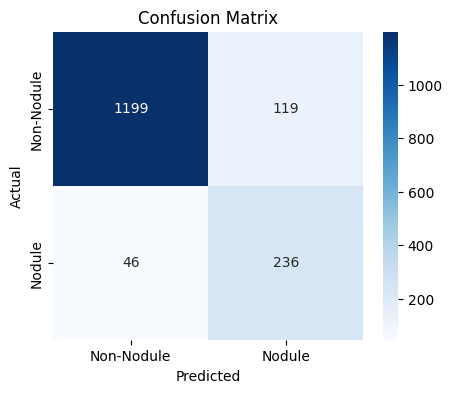

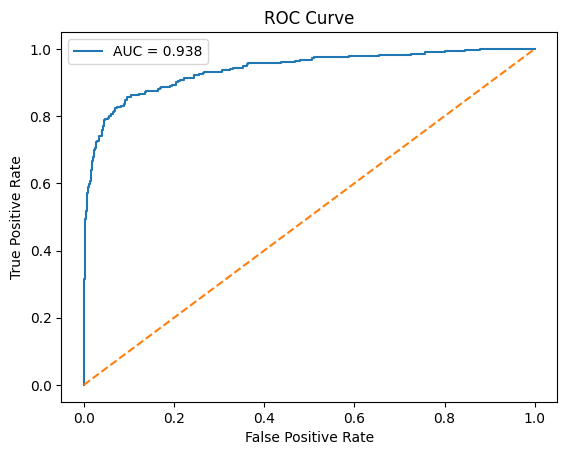

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

y_true, y_score = [], []

global_model.eval()
with torch.no_grad():
    for x,y in test_loader:
        x = x.to(DEVICE)
        probs = torch.sigmoid(global_model(x)).cpu().numpy()
        y_score.extend(probs)
        y_true.extend(y.numpy())

# Confusion Matrix
y_pred = (np.array(y_score) > 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Nodule","Nodule"],
            yticklabels=["Non-Nodule","Nodule"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x):
        self.model.zero_grad()
        out = self.model(x)
        out.backward()

        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)
        cam = cam / cam.max()
        return cam


In [ ]:
import torch.linalg as LA

def compute_drift(local_w, global_w):
    return sum(LA.norm(local_w[k] - global_w[k]).item()
               for k in global_w.keys())


In [ ]:
client_drift_history = [[] for _ in range(len(client_loaders))]

for rnd in range(10):
    local_weights = []

    for i, loader in enumerate(client_loaders):
        local_model = HybridLungNet().to(DEVICE)
        local_model.load_state_dict(global_model.state_dict())

        lr, wd = pso_sample_lr()
        opt = torch.optim.Adam(local_model.parameters(), lr=lr, weight_decay=wd)
        loss_fn = nn.BCEWithLogitsLoss()

        for x,y in loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(local_model(x).squeeze(), y.float())
            loss.backward()
            opt.step()

        drift = compute_drift(local_model.state_dict(),
                              global_model.state_dict())
        client_drift_history[i].append(drift)
        local_weights.append(local_model.state_dict())

    global_model.load_state_dict(fed_avg(local_weights))


In [ ]:
for i, drift in enumerate(client_drift_history):
    plt.plot(drift, label=f"Client {i+1}")

plt.xlabel("Federated Rounds")
plt.ylabel("Drift Magnitude")
plt.title("Client Drift Across Rounds")
plt.legend()
plt.show()
